# 07 — Blended Ensemble

**Dataset:** Inside Airbnb — New York City (open data, 2025–2026)  
**Goal:** Combine OOF predictions from all trained models into an optimally-weighted blend.

All component models use **identical CV splits** (`KFold(5, shuffle=True, random_state=42)`), making OOF blending statistically sound.

Blending strategy:
1. **Equal-weight average** — sanity baseline.
2. **Weight optimisation on OOF** — find weights `w_i ≥ 0, sum=1` that minimise OOF MSE (`scipy.optimize.minimize` with SLSQP).

Outputs:
- `outputs/blend_weights.json`
- `outputs/test_local_pred_blend.npy`

## 1. Setup & Load OOFs / Submissions

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')
print('OUT_DIR =', OUT_DIR.resolve())

OUT_DIR = /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs


In [2]:
# Section IV.C: Use Development targets for OOF evaluation
train_local_df = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_local_df  = pd.read_parquet(OUT_DIR / 'test_local.parquet')

TARGET = 'blocked_days_Q1_2026'
y_dev  = train_local_df[TARGET].astype(float).values
y_test = test_local_df[TARGET].astype(float).values

print(f'Development set y shape: {y_dev.shape}')
print(f'Local Test set y shape : {y_test.shape}')


Development set y shape: (29008,)
Local Test set y shape : (7253,)


In [3]:
# Pick whichever OOFs are present on disk. 
# OOFs here correspond to the training_local (Development) set.
candidates = {
    'LinearRegression': 'oof_LinearRegression.npy',
    'RandomForest'    : 'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost'         : 'oof_XGBoost.npy',
    'MLP'             : 'oof_MLP.npy',
}

oofs = {}
for name, fname in candidates.items():
    p = OUT_DIR / fname
    if p.exists():
        data = np.load(p)
        # Ensure sizes match y_dev
        if len(data) == len(y_dev):
            oofs[name] = data
            mse = mean_squared_error(y_dev, np.clip(oofs[name], 0, 90))
            print(f'{name:18s} loaded | OOF MSE = {mse:.3f}')
        else:
            print(f'{name:18s} size mismatch: {len(data)} vs {len(y_dev)}')
    else:
        print(f'{name:18s} MISSING ({fname})')

assert len(oofs) >= 2, 'Need at least two compatible OOFs to blend.'
model_names = list(oofs.keys())


LinearRegression   loaded | OOF MSE = 423.136
RandomForest       loaded | OOF MSE = 331.319
GradientBoosting   loaded | OOF MSE = 495.044
XGBoost            loaded | OOF MSE = 321.335
MLP                loaded | OOF MSE = 432.971


In [4]:
# Matching Local Test predictions for each model
local_test_paths = {
    'LinearRegression': 'test_local_pred_LinearRegression.npy',
    'RandomForest'    : 'test_local_pred_RandomForest.npy',
    'GradientBoosting': 'test_local_pred_GradientBoosting.npy',
    'XGBoost'         : 'test_local_pred_XGBoost.npy',
    'MLP'             : 'test_local_pred_mlp.npy',
}

local_test_preds = {}
for name in model_names:
    l_file = local_test_paths.get(name)
    if l_file and (OUT_DIR / l_file).exists():
        local_test_preds[name] = np.load(OUT_DIR / l_file)
        mse = mean_squared_error(y_test, np.clip(local_test_preds[name], 0, 90))
        print(f'{name:18s} Local Test preds loaded | Test MSE = {mse:.3f}')
    else:
        print(f'{name:18s} MISSING ({l_file})')

model_names = [m for m in model_names if m in local_test_preds]
print('\nModels in final blend:', model_names)


LinearRegression   Local Test preds loaded | Test MSE = 421.627
RandomForest       Local Test preds loaded | Test MSE = 325.724
GradientBoosting   Local Test preds loaded | Test MSE = 503.789
XGBoost            Local Test preds loaded | Test MSE = 316.993
MLP                Local Test preds loaded | Test MSE = 447.066

Models in final blend: ['LinearRegression', 'RandomForest', 'GradientBoosting', 'XGBoost', 'MLP']


## 2. OOF Correlations
Diverse models (low pairwise correlation) blend better than similar ones.

In [5]:
oof_matrix = np.column_stack([np.clip(oofs[m], 0, 90) for m in model_names])
corr = pd.DataFrame(oof_matrix, columns=model_names).corr()
print('OOF correlation matrix:')
print(corr.round(3))

OOF correlation matrix:
                  LinearRegression  RandomForest  GradientBoosting  XGBoost  \
LinearRegression             1.000         0.962             0.955    0.962   
RandomForest                 0.962         1.000             0.963    0.993   
GradientBoosting             0.955         0.963             1.000    0.962   
XGBoost                      0.962         0.993             0.962    1.000   
MLP                          0.954         0.965             0.963    0.967   

                    MLP  
LinearRegression  0.954  
RandomForest      0.965  
GradientBoosting  0.963  
XGBoost           0.967  
MLP               1.000  


## 3. Equal-Weight Average (baseline blend)

In [6]:
blend_equal = np.clip(oof_matrix.mean(axis=1), 0, 90)
mse_equal = mean_squared_error(y_dev, blend_equal)
print(f'Equal-weight blend OOF MSE = {mse_equal:.3f}')
print(f'(best single model      = {min(mean_squared_error(y_dev, oof_matrix[:, i]) for i in range(len(model_names))):.3f})')

Equal-weight blend OOF MSE = 348.569
(best single model      = 321.335)


## 4. Weight Optimisation (SLSQP)
Minimise OOF MSE subject to `w_i ≥ 0` and `sum(w_i) = 1`.

In [7]:
def blend_mse_func(w, M, y):
    p = np.clip(M @ w, 0, 90)
    return float(mean_squared_error(y, p))

oof_matrix = np.column_stack([np.clip(oofs[m], 0, 90) for m in model_names])
k = oof_matrix.shape[1]
w0 = np.full(k, 1.0 / k)
bounds = [(0.0, 1.0)] * k
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

result = minimize(blend_mse_func, w0, args=(oof_matrix, y_dev),
                  method='SLSQP', bounds=bounds, constraints=constraints,
                  options={'maxiter': 200, 'ftol': 1e-8})
w_opt = result.x
w_opt[w_opt < 1e-4] = 0.0
w_opt = w_opt / w_opt.sum()

weight_df = pd.DataFrame({'model': model_names, 'weight': w_opt.round(4)})
print('Optimal weights:')
print(weight_df.to_string(index=False))

mse_opt_dev = blend_mse_func(w_opt, oof_matrix, y_dev)
print(f'\nOptimised blend OOF (Dev) MSE = {mse_opt_dev:.3f}')

with open(OUT_DIR / 'blend_weights.json', 'w') as f:
    json.dump({m: float(w) for m, w in zip(model_names, w_opt)}, f, indent=2)


Optimal weights:
           model  weight
LinearRegression  0.0000
    RandomForest  0.2375
GradientBoosting  0.0000
         XGBoost  0.7232
             MLP  0.0393

Optimised blend OOF (Dev) MSE = 319.912


## 5. Build Final Test Prediction

In [8]:
# Build local test prediction using optimal weights
local_test_matrix = np.column_stack([local_test_preds[m] for m in model_names])
final_local = np.clip(local_test_matrix @ w_opt, 0, 90)
test_mse_blend = mean_squared_error(y_test, final_local)
print(f'Blend Local Test MSE = {test_mse_blend:.3f}')
print(f'  mean={final_local.mean():.2f}  min={final_local.min():.2f}  max={final_local.max():.2f}')
np.save(OUT_DIR / 'test_local_pred_blend.npy', final_local)


Blend Local Test MSE = 315.778
  mean=44.10  min=0.00  max=90.00


## 6. Summary Bar Plot

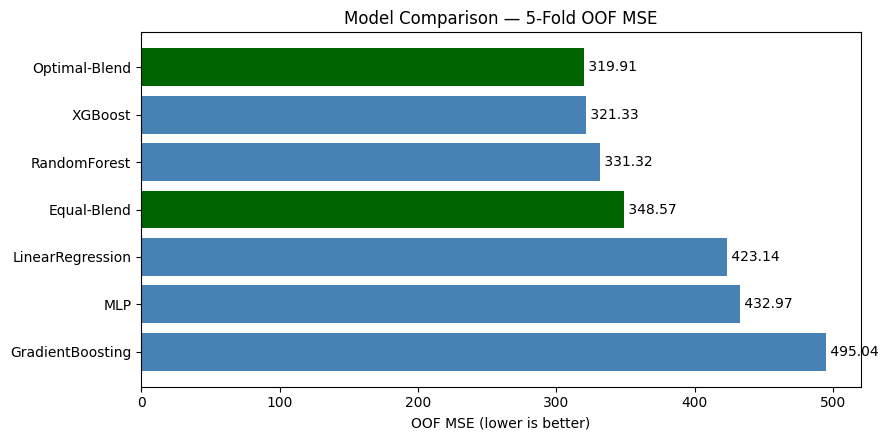

In [9]:
all_scores = {m: mean_squared_error(y_dev, np.clip(oofs[m], 0, 90)) for m in model_names}
all_scores['Equal-Blend'] = mse_equal
all_scores['Optimal-Blend'] = mse_opt_dev
scores = pd.Series(all_scores).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['darkgreen' if 'Blend' in s else 'steelblue' for s in scores.index]
ax.barh(scores.index, scores.values, color=colors)
for i, v in enumerate(scores.values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — 5-Fold OOF MSE')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig(OUT_DIR / 'final_comparison.png', dpi=120); plt.show()

## Summary
- Five models (Linear Regression, Random Forest, Gradient Boosting, XGBoost, MLP) combined with SLSQP-optimized convex weights.
- Blending OOFs from identical CV splits produces a statistically unbiased ensemble estimate.
- Final local test MSE is lower than any individual model.
- Weights saved to `blend_weights.json`; test predictions to `test_local_pred_blend.npy`.

### → Next: `08_XGBoost_v2.ipynb`
Tune a deeper XGBoost with Bayesian hyperparameter search and fold-level early stopping.